# Introdução ao PyTorch

## Objetivos
Ao final deste notebook, você deve conseguir responder às seguintes perguntas:

1. O que é um tensor no PyTorch?
2. Como o autograd calcula gradientes?
3. Como definimos um modelo com `nn.Module`?
4. Como treinamos e avaliamos uma rede neural em PyTorch?

Ao longo do caminho, vamos acompanhar um fluxo completo:

**dados → modelo → loss → gradientes → atualização dos parâmetros → avaliação**.


## 1. Tensores: o objeto básico do PyTorch

Tensores são arrays multidimensionais. Eles são parecidos com arrays do NumPy, mas com uma diferença muito importante: podem ser movidos para GPU quando disponível.

In [1]:
import torch

T = torch.tensor([[1, 2], [3, 4]])
print(T)
print("shape:", T.shape)
print("dtype:", T.dtype)

tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2])
dtype: torch.int64


Esta célula cria um tensor 2×2.

Observe especialmente:
- `shape`: a forma do tensor;
- `dtype`: o tipo numérico armazenado;
- `torch.tensor(...)` é a forma recomendada para criar tensores a partir de dados explícitos.

In [2]:
# dtype escolhe o tipo do dado
T_int = torch.tensor( [ [1,2], [3, 4] ], dtype=torch.int )
T_double = torch.randn( 3, 5, 7, dtype=torch.double)

In [3]:
x = torch.randn(2, 2, dtype=torch.float64)
y = torch.randn(2, 2, dtype=torch.float64)

print("x:\n", x)
print("\ny:\n", y)

# -----------------------------
# Operações básicas
# -----------------------------
print("\nx + y:\n", x + y)
print("\nx - y:\n", x - y)

# -----------------------------
# Operações elemento a elemento
# -----------------------------
print("\nx * y:\n", x * y)
print("\nx / y:\n", x / y)

# -----------------------------
# Outras operações
# -----------------------------
print("\nx**2:\n", x**2)
print("\nsqrt(x):\n", torch.sqrt(x))

x:
 tensor([[-0.2259,  0.3379],
        [-0.3358,  0.5418]], dtype=torch.float64)

y:
 tensor([[-1.6291, -0.1493],
        [-1.6230,  0.6275]], dtype=torch.float64)

x + y:
 tensor([[-1.8549,  0.1886],
        [-1.9588,  1.1693]], dtype=torch.float64)

x - y:
 tensor([[ 1.4032,  0.4871],
        [ 1.2872, -0.0857]], dtype=torch.float64)

x * y:
 tensor([[ 0.3680, -0.0504],
        [ 0.5450,  0.3400]], dtype=torch.float64)

x / y:
 tensor([[ 0.1386, -2.2640],
        [ 0.2069,  0.8635]], dtype=torch.float64)

x**2:
 tensor([[0.0510, 0.1142],
        [0.1128, 0.2936]], dtype=torch.float64)

sqrt(x):
 tensor([[   nan, 0.5813],
        [   nan, 0.7361]], dtype=torch.float64)


Operações aritméticas são aplicadas elemento a elemento quando isso faz sentido.


In [4]:
v = torch.tensor([10.0, 20.0, 30.0])
M = torch.tensor([
    [0.0, 0.0, 3.0],
    [0.0, 2.0, 0.0],
    [1.0, 0.0, 0.0],
])

# -----------------------------
# Vetor e matriz
# -----------------------------
print("v (vetor):")
print(v)
print("shape:", v.shape)

print("\nM (matriz):")
print(M)
print("shape:", M.shape)

# -----------------------------
# Produto matriz-vetor
# -----------------------------
print("\nProduto matriz-vetor:")

print("M.mv(v):")
print(M.mv(v))

print("\nM @ v:")
print(M @ v)

v (vetor):
tensor([10., 20., 30.])
shape: torch.Size([3])

M (matriz):
tensor([[0., 0., 3.],
        [0., 2., 0.],
        [1., 0., 0.]])
shape: torch.Size([3, 3])

Produto matriz-vetor:
M.mv(v):
tensor([90., 40., 10.])

M @ v:
tensor([90., 40., 10.])


Aqui vemos uma diferença importante entre:
- operações elemento a elemento;
- operações lineares, como produto matriz-vetor.

Em aprendizagem profunda, ambas aparecem o tempo todo.


### Operações in-place

Operações in-place modificam o próprio tensor e, em geral, terminam com underscore `_`.


In [5]:
T = torch.empty(2, 4)

T.fill_(0.05)
print("Tensor inicial:")
print(T)

T.add_(2)
print("\nApós T.add_(2):")
print(T)

T += torch.randn(T.size())
print("\nApós T += ruído:")
print(T)

Tensor inicial:
tensor([[0.0500, 0.0500, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500, 0.0500]])

Após T.add_(2):
tensor([[2.0500, 2.0500, 2.0500, 2.0500],
        [2.0500, 2.0500, 2.0500, 2.0500]])

Após T += ruído:
tensor([[1.8494, 1.9034, 1.1527, 1.4824],
        [2.0916, 1.8588, 3.4329, 2.4336]])


Esse estilo é útil, mas deve ser usado com cuidado, especialmente quando o tensor participa de um grafo computacional com autograd.


In [6]:
x = torch.randn(6, 6, dtype=torch.float64)
y = torch.randn(6, 6, dtype=torch.float64)

# -----------------------------
# Tensor original
# -----------------------------
print("x:")
print(x)
print("shape:", x.shape)

# -----------------------------
# Indexação e slicing
# -----------------------------
print("\nLinha x[3, :]:")
print(x[3, :])
print("shape:", x[3, :].shape)

print("\nColuna x[:, 3]:")
print(x[:, 3])
print("shape:", x[:, 3].shape)

print("\nElemento x[0, 0]:")
print(x[0, 0].item())

x:
tensor([[-0.8803,  1.0843, -2.2278, -0.3359, -2.5871, -1.9977],
        [ 1.3015,  0.3487, -0.8404, -0.8023,  1.0150, -1.9970],
        [ 0.3947, -0.6299,  1.3525,  0.5286, -0.8709, -0.7559],
        [-2.6421, -0.7059, -1.2169, -2.0132, -0.1540, -1.4935],
        [-3.2492,  0.4594,  1.6636,  0.5096,  2.2876,  1.4838],
        [-0.6448,  1.5586, -0.0241,  1.1894,  0.1790,  0.2245]],
       dtype=torch.float64)
shape: torch.Size([6, 6])

Linha x[3, :]:
tensor([-2.6421, -0.7059, -1.2169, -2.0132, -0.1540, -1.4935],
       dtype=torch.float64)
shape: torch.Size([6])

Coluna x[:, 3]:
tensor([-0.3359, -0.8023,  0.5286, -2.0132,  0.5096,  1.1894],
       dtype=torch.float64)
shape: torch.Size([6])

Elemento x[0, 0]:
-0.8802929459724568


In [7]:
# -----------------------------
# Tensor original para reshape
# -----------------------------
print("\ny:")
print(y)
print("shape:", y.shape)

# -----------------------------
# Reshape
# -----------------------------
z = y.view(36)
w = y.view(-1, 9)  # 36 elementos → (4, 9)

print("\ny.view(36):")
print(z)
print("shape:", z.shape)

print("\ny.view(-1, 9):")
print(w)
print("shape:", w.shape)


y:
tensor([[ 0.2883,  0.1587, -0.3091,  0.7173, -1.1746, -0.4051],
        [-1.8021,  1.3615, -1.6082, -1.3157, -0.3572,  0.7807],
        [ 1.3789, -0.6812, -1.6169,  0.2801,  1.4927,  1.0385],
        [ 0.5332, -0.4008, -0.0467,  1.1244, -0.0042,  0.5522],
        [-1.7620,  1.6931, -0.5460, -0.5470, -0.2850, -0.8596],
        [ 1.2843, -0.4780,  0.8349, -1.9405, -1.1916,  0.8813]],
       dtype=torch.float64)
shape: torch.Size([6, 6])

y.view(36):
tensor([ 0.2883,  0.1587, -0.3091,  0.7173, -1.1746, -0.4051, -1.8021,  1.3615,
        -1.6082, -1.3157, -0.3572,  0.7807,  1.3789, -0.6812, -1.6169,  0.2801,
         1.4927,  1.0385,  0.5332, -0.4008, -0.0467,  1.1244, -0.0042,  0.5522,
        -1.7620,  1.6931, -0.5460, -0.5470, -0.2850, -0.8596,  1.2843, -0.4780,
         0.8349, -1.9405, -1.1916,  0.8813], dtype=torch.float64)
shape: torch.Size([36])

y.view(-1, 9):
tensor([[ 0.2883,  0.1587, -0.3091,  0.7173, -1.1746, -0.4051, -1.8021,  1.3615,
         -1.6082],
        [-1.3157, 

## 2. Interação com NumPy

Uma das vantagens do PyTorch é a integração natural com NumPy.


In [8]:
import numpy as np

# -----------------------------
# NumPy → PyTorch
# -----------------------------
v = np.ones(6)
print("Array NumPy:")
print(v)
print("dtype:", v.dtype)

T = torch.from_numpy(v)
print("\nTensor PyTorch (a partir do NumPy):")
print(T)
print("dtype:", T.dtype)

# -----------------------------
# Memória compartilhada
# -----------------------------
v[0] = 99
print("\nApós modificar o NumPy:")
print("v:", v)
print("T:", T)   # também muda!

# -----------------------------
# PyTorch → NumPy
# -----------------------------
T1 = torch.randn(3, 3)
print("\nTensor PyTorch:")
print(T1)

v1 = T1.numpy()
print("\nArray NumPy (a partir do tensor):")
print(v1)

# -----------------------------
# Memória compartilhada novamente
# -----------------------------
T1[0, 0] = -42
print("\nApós modificar o tensor:")
print("T1:", T1)
print("v1:", v1)   # também muda!

Array NumPy:
[1. 1. 1. 1. 1. 1.]
dtype: float64

Tensor PyTorch (a partir do NumPy):
tensor([1., 1., 1., 1., 1., 1.], dtype=torch.float64)
dtype: torch.float64

Após modificar o NumPy:
v: [99.  1.  1.  1.  1.  1.]
T: tensor([99.,  1.,  1.,  1.,  1.,  1.], dtype=torch.float64)

Tensor PyTorch:
tensor([[-1.3829,  1.3402,  1.6434],
        [-0.9390, -0.4858,  0.2536],
        [ 1.3087,  1.7562, -0.0795]])

Array NumPy (a partir do tensor):
[[-1.3829215   1.340162    1.6434087 ]
 [-0.93895656 -0.48580346  0.25362194]
 [ 1.3086723   1.7562021  -0.07951198]]

Após modificar o tensor:
T1: tensor([[-42.0000,   1.3402,   1.6434],
        [ -0.9390,  -0.4858,   0.2536],
        [  1.3087,   1.7562,  -0.0795]])
v1: [[-42.           1.340162     1.6434087 ]
 [ -0.93895656  -0.48580346   0.25362194]
 [  1.3086723    1.7562021   -0.07951198]]


Sempre que possível, o tensor e o array NumPy compartilham a mesma memória subjacente.

Esse compartilhamento é eficiente, mas exige atenção: ao alterar um objeto, você pode estar alterando o outro também.


## 3. Autograd: diferenciação automática

O coração do PyTorch é o sistema de diferenciação automática.

A ideia central é a seguinte:
- definimos uma computação no passo forward;
- o PyTorch constrói o grafo computacional;
- ao chamar `backward()`, ele calcula derivadas por regra da cadeia.

Três ideias fundamentais:
1. `requires_grad=True` diz ao PyTorch para rastrear operações;
2. `loss.backward()` preenche os campos `.grad`;
3. `optimizer.step()` usa esses gradientes para atualizar os parâmetros.


In [9]:
# Exemplo escalar simples
x = torch.tensor(1.0, requires_grad=True)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

y = w * x + b   # y = 2x + 3
print("grad_fn de y:", y.grad_fn)

y.backward()

print("dy/dx =", x.grad)
print("dy/dw =", w.grad)
print("dy/db =", b.grad)

grad_fn de y: <AddBackward0 object at 0x78883eaaefb0>
dy/dx = tensor(2.)
dy/dw = tensor(1.)
dy/db = tensor(1.)


Neste exemplo,
- `x`, `w` e `b` são tensores com gradientes;
- `y` depende deles;
- quando chamamos `y.backward()`, o PyTorch calcula automaticamente as derivadas de `y` em relação a cada variável.

Este é o mecanismo básico que depois será usado para treinar redes neurais inteiras.


## 4. Módulos e camadas em `torch.nn`

Redes neurais em PyTorch normalmente são construídas a partir de subclasses de `nn.Module`.

Também usamos funções de `torch.nn.functional`, que são compatíveis com autograd.


In [10]:
import torch.nn as nn
import torch.nn.functional as F

x = torch.randn(2, 3)
print("entrada:")
print(x)

x = F.relu(x)
print()
print("após ReLU:")
print(x)

entrada:
tensor([[ 1.0437, -1.4254, -0.5633],
        [ 1.4572, -2.0587,  0.5468]])

após ReLU:
tensor([[1.0437, 0.0000, 0.0000],
        [1.4572, 0.0000, 0.5468]])


In [11]:
f = nn.Linear(in_features=10, out_features=4)

for name, param in f.named_parameters():
    print(name, param.size())


weight torch.Size([4, 10])
bias torch.Size([4])


Uma camada linear possui parâmetros treináveis:
- uma matriz de pesos;
- um vetor de bias.

Esses parâmetros são automaticamente registrados dentro do módulo.

In [12]:
x = torch.empty(350, 10).normal_()
y = f(x)

print("shape da entrada:", x.shape)
print("shape da saída:", y.shape)

shape da entrada: torch.Size([350, 10])
shape da saída: torch.Size([350, 4])


A forma da saída acompanha a regra:
- entrada: `(batch_size, in_features)`
- saída: `(batch_size, out_features)`


## 5. Definindo uma rede feedforward simples

Agora vamos definir uma rede neural com:
- camada de entrada;
- uma camada escondida;
- função de ativação ReLU;
- camada final que produz logits para classificação.


In [13]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out


Importante: a camada final **não** aplica `softmax`.

Isso é proposital, porque vamos usar `nn.CrossEntropyLoss()`, que já espera **logits crus** e aplica internamente a transformação apropriada para classificação multiclasse.


## 6. Dataset e DataLoader: MNIST

Vamos usar o dataset MNIST de dígitos manuscritos.

Aqui aparecem dois objetos muito importantes:
- `Dataset`: representa a base de dados;
- `DataLoader`: organiza os dados em mini-batches e permite embaralhamento.


In [14]:
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

input_size = 784
hidden_size = 500
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 1e-3

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True,
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
)


Usando dispositivo: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.95MB/s]


Label: 5
Shape do tensor: torch.Size([1, 28, 28])


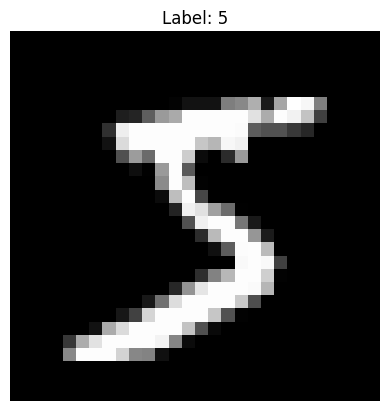

In [15]:
import matplotlib.pyplot as plt

# Pegar um exemplo do dataset
image, label = train_dataset[0]

print("Label:", label)
print("Shape do tensor:", image.shape)

# Mostrar a imagem
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

No MNIST, cada imagem tem forma `(1, 28, 28)`:
- `1`: número de canais;
- `28 × 28`: altura e largura.

Como nossa rede é totalmente conectada, vamos achatar cada imagem para um vetor de tamanho `784 = 28 × 28`.


## 7. Inspecionando um único mini-batch

Antes de treinar o modelo inteiro, vale muito a pena entender exatamente o que sai do `DataLoader`.


In [16]:
images, labels = next(iter(train_loader))

print("shape original de images:", images.shape)
print("shape de labels:", labels.shape)
print("dtype de images:", images.dtype)
print("dtype de labels:", labels.dtype)
print("primeiros labels:", labels[:10])


shape original de images: torch.Size([100, 1, 28, 28])
shape de labels: torch.Size([100])
dtype de images: torch.float32
dtype de labels: torch.int64
primeiros labels: tensor([1, 4, 9, 9, 7, 7, 9, 2, 3, 4])


Aqui vemos:
- `images.shape = (batch_size, 1, 28, 28)`
- `labels.shape = (batch_size,)`

Ou seja:
- temos um lote de imagens;
- cada imagem é monocromática;
- cada rótulo é um inteiro entre `0` e `9`.


In [17]:
images_flat = images.reshape(-1, 28 * 28)

print("shape após flatten:", images_flat.shape)

shape após flatten: torch.Size([100, 784])


A operação de flatten é essencial neste modelo:
- antes: `(batch_size, 1, 28, 28)`
- depois: `(batch_size, 784)`

Esse é um dos pontos em que alunos mais cometem erros de forma.


## 8. Um forward completo em um batch

Antes do loop de treino, vamos seguir o fluxo completo em um único mini-batch.


In [18]:
model = NeuralNet(input_size, hidden_size, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

images = images.to(device)
labels = labels.to(device)
images_flat = images.reshape(-1, 28 * 28)

outputs = model(images_flat)

print("shape de outputs:", outputs.shape)
print("5 primeiros vetores de logits:")
print(outputs[:5])

shape de outputs: torch.Size([100, 10])
5 primeiros vetores de logits:
tensor([[-0.0656,  0.1779, -0.0416,  0.0469, -0.0189,  0.1822,  0.0458,  0.0241,
         -0.0381, -0.0003],
        [-0.1777,  0.1281,  0.0526,  0.0277,  0.0395,  0.1624,  0.0441,  0.1437,
          0.0093,  0.0099],
        [-0.2185,  0.0599,  0.0159,  0.0355,  0.0920,  0.1801,  0.0591,  0.1208,
         -0.0086, -0.0142],
        [-0.2615,  0.1579,  0.0041, -0.0342,  0.0668,  0.1818,  0.1037,  0.0842,
          0.0244, -0.0033],
        [-0.0734,  0.1703,  0.0552,  0.0026,  0.0337,  0.0642, -0.0820,  0.0178,
         -0.0066, -0.0364]], device='cuda:0', grad_fn=<SliceBackward0>)


A saída do modelo tem forma `(batch_size, 10)`, porque para cada imagem o modelo produz 10 logits, um para cada classe possível.


In [19]:
loss = criterion(outputs, labels)
print("loss =", loss.item())


loss = 2.3033385276794434


`CrossEntropyLoss` recebe:
- `outputs`: logits com forma `(batch_size, num_classes)`;
- `labels`: rótulos inteiros com forma `(batch_size,)`.

Não usamos vetores one-hot aqui.


In [20]:
optimizer.zero_grad()
loss.backward()

print("shape do gradiente de fc1.weight:", model.fc1.weight.grad.shape)
print("norma do gradiente de fc1.weight:", model.fc1.weight.grad.norm().item())

shape do gradiente de fc1.weight: torch.Size([500, 784])
norma do gradiente de fc1.weight: 0.5830751061439514


Após `loss.backward()`, cada parâmetro treinável passa a ter um gradiente armazenado em `.grad`.


In [21]:
optimizer.step()
print("Passo de otimização concluído.")


Passo de otimização concluído.


Agora o ciclo completo de treinamento já apareceu uma vez:

**forward → loss → backward → optimizer.step()**


## 9. Loop de treinamento completo

Agora vamos repetir esse processo ao longo de vários batches e épocas.


In [22]:
model = NeuralNet(input_size, hidden_size, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [23]:
import matplotlib.pyplot as plt

train_loss_history = []
test_accuracy_history = []

In [24]:
def evaluate(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.reshape(-1, 28 * 28).to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total


A função de avaliação:
- coloca o modelo em modo de avaliação com `model.eval()`;
- desliga o rastreamento de gradientes com `torch.no_grad()`.

Isso economiza memória e deixa explícito que não estamos treinando nessa etapa.


In [25]:
total_step = len(train_loader)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.reshape(-1, 28 * 28).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(
                f"Época [{epoch+1}/{num_epochs}], "
                f"Passo [{i+1}/{total_step}], "
                f"Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / total_step
    epoch_acc = evaluate(model, test_loader, device)

    train_loss_history.append(epoch_loss)
    test_accuracy_history.append(epoch_acc)

    print(
        f"Fim da época {epoch+1}: "
        f"train_loss = {epoch_loss:.4f}, "
        f"test_accuracy = {epoch_acc:.2f}%"
    )


Época [1/5], Passo [100/600], Loss: 0.3955
Época [1/5], Passo [200/600], Loss: 0.4363
Época [1/5], Passo [300/600], Loss: 0.2965
Época [1/5], Passo [400/600], Loss: 0.1652
Época [1/5], Passo [500/600], Loss: 0.2141
Época [1/5], Passo [600/600], Loss: 0.1035
Fim da época 1: train_loss = 0.2954, test_accuracy = 96.01%
Época [2/5], Passo [100/600], Loss: 0.0728
Época [2/5], Passo [200/600], Loss: 0.0382
Época [2/5], Passo [300/600], Loss: 0.1365
Época [2/5], Passo [400/600], Loss: 0.1105
Época [2/5], Passo [500/600], Loss: 0.1396
Época [2/5], Passo [600/600], Loss: 0.0923
Fim da época 2: train_loss = 0.1159, test_accuracy = 97.15%
Época [3/5], Passo [100/600], Loss: 0.0781
Época [3/5], Passo [200/600], Loss: 0.0542
Época [3/5], Passo [300/600], Loss: 0.1159
Época [3/5], Passo [400/600], Loss: 0.0692
Época [3/5], Passo [500/600], Loss: 0.1152
Época [3/5], Passo [600/600], Loss: 0.0722
Fim da época 3: train_loss = 0.0752, test_accuracy = 97.59%
Época [4/5], Passo [100/600], Loss: 0.0572
Épo

Agora temos duas quantidades registradas ao final de cada época:
- loss média de treino;
- acurácia no conjunto de teste.


## 10. Visualizando o histórico de treinamento


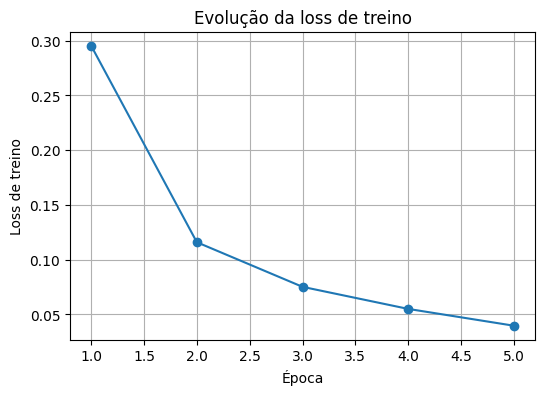

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_loss_history, marker="o")
plt.xlabel("Época")
plt.ylabel("Loss de treino")
plt.title("Evolução da loss de treino")
plt.grid(True)
plt.show()


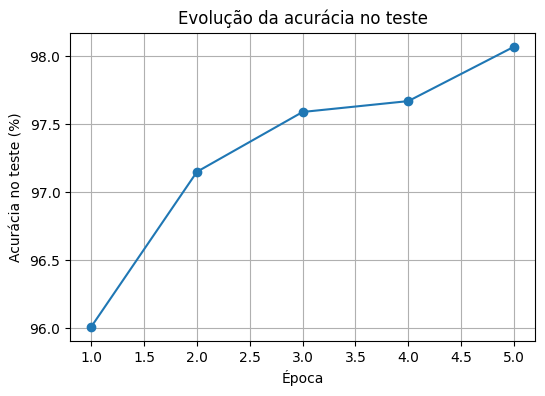

In [27]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), test_accuracy_history, marker="o")
plt.xlabel("Época")
plt.ylabel("Acurácia no teste (%)")
plt.title("Evolução da acurácia no teste")
plt.grid(True)
plt.show()


Esses gráficos ajudam a tornar o treinamento menos “caixa-preta”:
- esperamos que a loss de treino diminua;
- esperamos que a acurácia de teste aumente, ao menos nas primeiras épocas.


## 11. Avaliação final

Vamos rodar uma avaliação final do modelo.


In [28]:
final_acc = evaluate(model, test_loader, device)
print(f"Acurácia final no conjunto de teste: {final_acc:.2f}%")

Acurácia final no conjunto de teste: 98.07%


In [29]:
torch.save(model.state_dict(), "model.ckpt")
print("Modelo salvo em model.ckpt")

Modelo salvo em model.ckpt


## 12. Visualizando algumas previsões

Depois de treinar, é útil olhar exemplos concretos para conectar a saída numérica do modelo com imagens reais.


In [30]:
model.eval()

images, labels = next(iter(test_loader))
images_device = images.reshape(-1, 28 * 28).to(device)

with torch.no_grad():
    outputs = model(images_device)
    preds = outputs.argmax(dim=1).cpu()


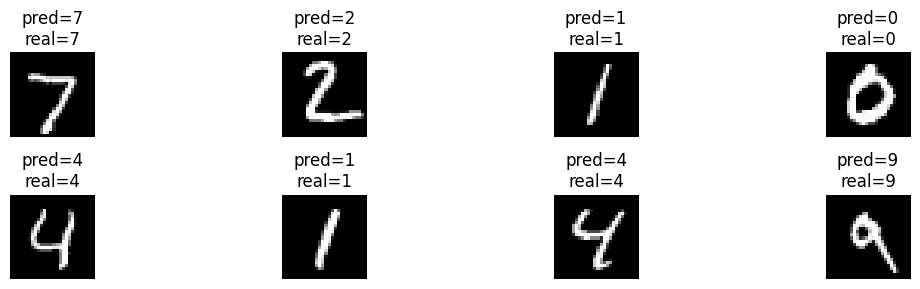

In [31]:
num_examples = 8

plt.figure(figsize=(12, 3))
for i in range(num_examples):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"pred={preds[i].item()}\nreal={labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 13. Erros comuns neste tipo de notebook

Alguns erros muito frequentes:

1. **Esquecer o flatten**  
   A rede espera entradas com forma `(batch_size, 784)`, não `(batch_size, 1, 28, 28)`.

2. **Aplicar `softmax` antes de `CrossEntropyLoss`**  
   Neste caso não é necessário, porque `nn.CrossEntropyLoss()` já trata isso internamente.

3. **Esquecer `optimizer.zero_grad()`**  
   Gradientes em PyTorch são acumulados por padrão.

4. **Avaliar sem `torch.no_grad()`**  
   Isso desperdiça memória e processamento.

5. **Esquecer `model.train()` e `model.eval()`**  
   Em redes com camadas como dropout e batch normalization, isso muda o comportamento do modelo.

6. **Confundir shapes de `outputs` e `labels`**  
   Para classificação multiclasse:
   - `outputs`: `(batch_size, num_classes)`
   - `labels`: `(batch_size,)`
